# Concentration Curves

This notebook validates, combines, plots, and exports the country-level concentration curves used across multiple parts of the national tool. Curve definitions and interpretation metadata come from the explicit registry in `config/countries/KEN.toml`.

## Concentration-Curve Construction

Upstream observations are ordered by the registered ranking variable and direction. Cumulative population and cumulative outcome are each divided by their totals, explicit `(0, 0)` and `(1, 1)` endpoints are included, and the result is placed on the shared population-share grid. This notebook consumes those precomputed points; it does not silently resample them.

## 0. Setup

Shared loading and validation logic lives in `src/national_tool_metrics/concentration_curves.py`. The input and output contract is documented in `docs/concentration_curves.md`.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt

WORKING_DIRECTORY = Path.cwd().resolve()
REPO_ROOT = WORKING_DIRECTORY.parent if WORKING_DIRECTORY.name == "notebooks" else WORKING_DIRECTORY
SRC_DIRECTORY = REPO_ROOT / "src"
if str(SRC_DIRECTORY) not in sys.path:
    sys.path.insert(0, str(SRC_DIRECTORY))

from national_tool_metrics import load_country_config
from national_tool_metrics.concentration_curves import (
    SHARED_X_COLUMN,
    build_concentration_curve_output,
    concentration_curve_registry_frame,
    write_concentration_curve_output,
)

In [8]:
config = load_country_config("KEN", repo_root=REPO_ROOT)

print(f"Country: {config.country.name} ({config.country.iso3})")
print(f"Registered curves: {len(config.concentration_curves):,}")

Country: Kenya (KEN)
Registered curves: 1


## 1. Review the Registry

Check the stable curve identifiers, source columns, ranking direction, and descriptions before loading the raw CSVs. The registry order determines the output column order.

In [3]:
curve_registry = concentration_curve_registry_frame(config)
curve_registry

,curve_id,input_path,x_column,y_column,ranked_by,rank_direction,description
0,flood_risk__jrc__baseline_protected,data\raw\KEN\concentration_curves\KEN_jrc_prot...,frac_pop,frac_flood,relative_wealth,lowest_to_highest,Cumulative share of baseline protection-adjust...


## 2. Load, Validate, and Combine

Each curve must be bounded between 0 and 1, monotonic, start at `(0, 0)`, end at `(1, 1)`, and use the same cumulative-population-share grid as all other curves. The workflow deliberately does not interpolate mismatched inputs.

In [4]:
concentration_curves = build_concentration_curve_output(config)

print(f"Rows: {len(concentration_curves):,}")
print(f"Curve columns: {len(concentration_curves.columns) - 1:,}")
display(concentration_curves.head())
display(concentration_curves.tail())

Rows: 101
Curve columns: 1


,cumulative_population_share,flood_risk__jrc__baseline_protected
0,0.00,0.000000
1,0.01,0.012034
2,0.02,0.030063
3,0.03,0.040193
4,0.04,0.053312


,cumulative_population_share,flood_risk__jrc__baseline_protected
96,0.96,0.891916
97,0.97,0.892860
98,0.98,0.897975
99,0.99,0.985418
100,1.00,1.000000


## 3. Plot and Review

The dashed diagonal is the line of equality. Registry IDs are rendered with their three components separated for readability.

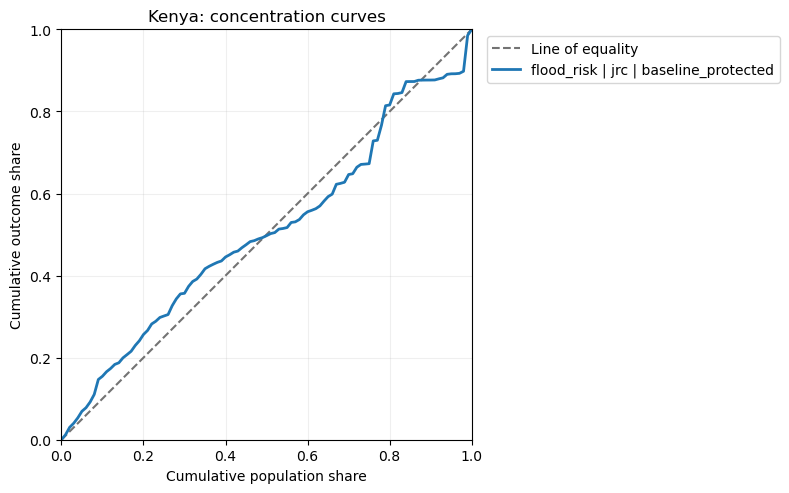

In [5]:
fig, ax = plt.subplots(figsize=(8, 8))
x_values = concentration_curves[SHARED_X_COLUMN]
ax.plot(x_values, x_values, linestyle="--", color="0.45", label="Line of equality")

for curve_id in config.concentration_curves:
    ax.plot(
        x_values,
        concentration_curves[curve_id],
        linewidth=2,
        label=curve_id.replace("__", " | "),
    )

ax.set(
    xlim=(0, 1),
    ylim=(0, 1),
    xlabel="Cumulative population share",
    ylabel="Cumulative outcome share",
    title=f"{config.country.name}: concentration curves",
)
ax.set_aspect("equal", adjustable="box")
ax.grid(alpha=0.2)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 4. Export

Write one country-level CSV with the shared cumulative population share in the first column and one column per registered concentration curve.

In [6]:
output_path = write_concentration_curve_output(concentration_curves, config)
print(f"Exported concentration curves to: {output_path}")

Exported concentration curves to: C:\Users\Mark.DESKTOP-UFHIN6T\Projects\national_tool_metrics\results\KEN\concentration_curves\KEN_concentration_curves.csv
